In [15]:
import pandas as pd
import numpy as np

In [16]:
df= pd.read_csv('train_data.csv')

In [17]:
df.head()

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,patientid,City_Code_Patient,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911.0,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954.0,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745.0,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272.0,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558.0,41-50


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital_code                      318438 non-null  int64  
 2   Hospital_type_code                 318438 non-null  object 
 3   City_Code_Hospital                 318438 non-null  int64  
 4   Hospital_region_code               318438 non-null  object 
 5   Available Extra Rooms in Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  object 
 7   Ward_Type                          318438 non-null  object 
 8   Ward_Facility_Code                 318438 non-null  object 
 9   Bed Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  3139

In [19]:
df.isnull().sum()

case_id                                 0
Hospital_code                           0
Hospital_type_code                      0
City_Code_Hospital                      0
Hospital_region_code                    0
Available Extra Rooms in Hospital       0
Department                              0
Ward_Type                               0
Ward_Facility_Code                      0
Bed Grade                             113
patientid                               0
City_Code_Patient                    4532
Type of Admission                       0
Severity of Illness                     0
Visitors with Patient                   0
Age                                     0
Admission_Deposit                       0
Stay                                    0
dtype: int64

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
for col in ['Department','Ward_Type','Type of Admission','Severity of Illness','Age','Stay']:
    print(f"\n{col}:")
    print(df[col].value_counts())


Department:
Department
gynecology            249486
anesthesia             29649
radiotherapy           28516
TB & Chest disease      9586
surgery                 1201
Name: count, dtype: int64

Ward_Type:
Ward_Type
R    127947
Q    106165
S     77794
P      5046
T      1477
U         9
Name: count, dtype: int64

Type of Admission:
Type of Admission
Trauma       152261
Emergency    117676
Urgent        48501
Name: count, dtype: int64

Severity of Illness:
Severity of Illness
Moderate    175843
Minor        85872
Extreme      56723
Name: count, dtype: int64

Age:
Age
41-50     63749
31-40     63639
51-60     48514
21-30     40843
71-80     35792
61-70     33687
11-20     16768
81-90      7890
0-10       6254
91-100     1302
Name: count, dtype: int64

Stay:
Stay
21-30                 87491
11-20                 78139
31-40                 55159
51-60                 35018
0-10                  23604
41-50                 11743
71-80                 10254
More than 100 Days     6683
81-9

In [22]:
df['Bed Grade'].value_counts()

Bed Grade
2.0    123671
3.0    110583
4.0     57566
1.0     26505
Name: count, dtype: int64

In [23]:
df['City_Code_Patient'].value_counts()

City_Code_Patient
8.0     124011
2.0      38869
1.0      26377
7.0      23807
5.0      20079
4.0      15380
9.0      11795
15.0      8950
10.0      8174
6.0       6005
12.0      5647
3.0       3772
23.0      3698
14.0      2927
16.0      2254
13.0      1625
21.0      1602
20.0      1409
18.0      1404
19.0      1028
26.0      1023
25.0       798
27.0       771
11.0       658
28.0       521
22.0       405
24.0       360
30.0       133
29.0        98
33.0        78
31.0        59
37.0        57
32.0        52
34.0        46
35.0        16
36.0        12
38.0         6
Name: count, dtype: int64

In [24]:
most_common_bed=df['Bed Grade'].mode()[0]
print("most common bed grade:",most_common_bed)
df['Bed Grade']=df['Bed Grade'].fillna(most_common_bed)
print("Missing values in Bed Grade:", df['Bed Grade'].isnull().sum())

most common bed grade: 2.0
Missing values in Bed Grade: 0


In [25]:
most_common_city=df['City_Code_Patient'].mode()[0]
print("most common city code:",most_common_city)
df['City_Code_Patient']=df['City_Code_Patient'].fillna(most_common_city)
print("Missing values in City_Code_Patient:", df['City_Code_Patient'].isnull().sum())

most common city code: 8.0
Missing values in City_Code_Patient: 0


In [26]:
 print(df['Age'].value_counts())
 print(df['Stay'].value_counts())

Age
41-50     63749
31-40     63639
51-60     48514
21-30     40843
71-80     35792
61-70     33687
11-20     16768
81-90      7890
0-10       6254
91-100     1302
Name: count, dtype: int64
Stay
21-30                 87491
11-20                 78139
31-40                 55159
51-60                 35018
0-10                  23604
41-50                 11743
71-80                 10254
More than 100 Days     6683
81-90                  4838
91-100                 2765
61-70                  2744
Name: count, dtype: int64


In [27]:
text_columns=['Department','Ward_Type','Type of Admission','Severity of Illness','Age','Stay']
for col in text_columns:
    df [col] = df [col].str.lower().str.strip()
    print(f"\n{col}:")
    print(df[col].value_counts())


Department:
Department
gynecology            249486
anesthesia             29649
radiotherapy           28516
tb & chest disease      9586
surgery                 1201
Name: count, dtype: int64

Ward_Type:
Ward_Type
r    127947
q    106165
s     77794
p      5046
t      1477
u         9
Name: count, dtype: int64

Type of Admission:
Type of Admission
trauma       152261
emergency    117676
urgent        48501
Name: count, dtype: int64

Severity of Illness:
Severity of Illness
moderate    175843
minor        85872
extreme      56723
Name: count, dtype: int64

Age:
Age
41-50     63749
31-40     63639
51-60     48514
21-30     40843
71-80     35792
61-70     33687
11-20     16768
81-90      7890
0-10       6254
91-100     1302
Name: count, dtype: int64

Stay:
Stay
21-30                 87491
11-20                 78139
31-40                 55159
51-60                 35018
0-10                  23604
41-50                 11743
71-80                 10254
more than 100 days     6683
81-9

In [28]:
age_mapping = {
    '0-10': 5,
    '11-20': 15.5,
    '21-30': 25.5,
    '31-40': 35.5,
    '41-50': 45.5,
    '51-60': 55.5,
    '61-70': 65.5,
    '71-80': 75.5,
    '81-90': 85.5,
    '91-100': 95.5
}
df['Age_numeric'] = df['Age'].map(age_mapping)

In [29]:
stay_mapping = {
    '0-10': 5,
    '11-20': 15.5,
    '21-30': 25.5,
    '31-40': 35.5,
    '41-50': 45.5,
    '51-60': 55.5,
    '61-70': 65.5,
    '71-80': 75.5,
    '81-90': 85.5,
    '91-100': 95.5,
    'more than 100 days': 150  
}
df['Stay_numeric'] = df['Stay'].map(stay_mapping)

In [30]:
df[['Age', 'Age_numeric','Stay','Stay_numeric']].head(10)

,Age,Age_numeric,Stay,Stay_numeric
0,51-60,55.5,0-10,5.0
1,51-60,55.5,41-50,45.5
2,51-60,55.5,31-40,35.5
3,51-60,55.5,41-50,45.5
4,51-60,55.5,41-50,45.5
5,51-60,55.5,11-20,15.5
6,51-60,55.5,0-10,5.0
7,51-60,55.5,41-50,45.5
8,51-60,55.5,51-60,55.5
9,51-60,55.5,31-40,35.5


In [31]:
print(df[['Age_numeric','Stay_numeric']].isnull().sum())

Age_numeric     0
Stay_numeric    0
dtype: int64


In [32]:
df[['Admission_Deposit','Visitors with Patient','Age_numeric','Stay_numeric']].describe()

,Admission_Deposit,Visitors with Patient,Age_numeric,Stay_numeric
count,318438.000000,318438.000000,318438.000000,318438.000000
mean,4880.749392,3.284099,46.767949,33.382355
std,1086.776254,1.764061,18.917238,25.326566
min,1800.000000,0.000000,5.000000,5.000000
25%,4186.000000,2.000000,35.500000,15.500000
50%,4741.000000,3.000000,45.500000,25.500000
75%,5409.000000,4.000000,55.500000,35.500000
max,11008.000000,32.000000,95.500000,150.000000


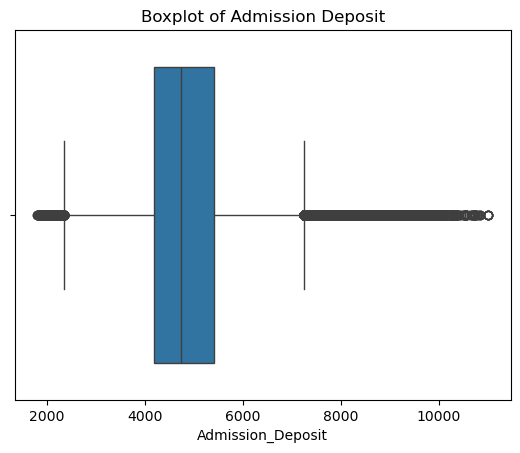

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot (x=df['Admission_Deposit'])
plt.title('Boxplot of Admission Deposit')
plt.show()

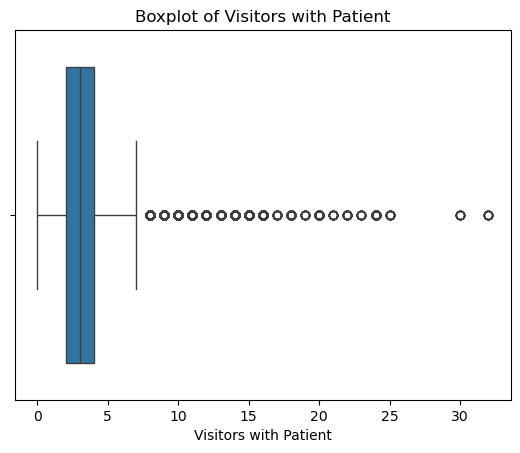

In [34]:
sns.boxplot (x=df['Visitors with Patient'])
plt.title('Boxplot of Visitors with Patient')
plt.show()

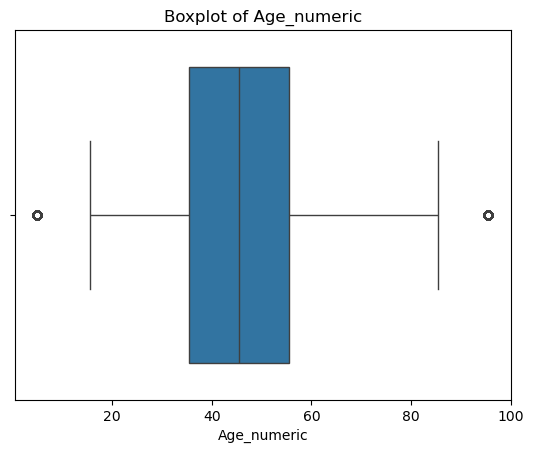

In [35]:
sns.boxplot (x=df['Age_numeric'])
plt.title('Boxplot of Age_numeric')
plt.show()

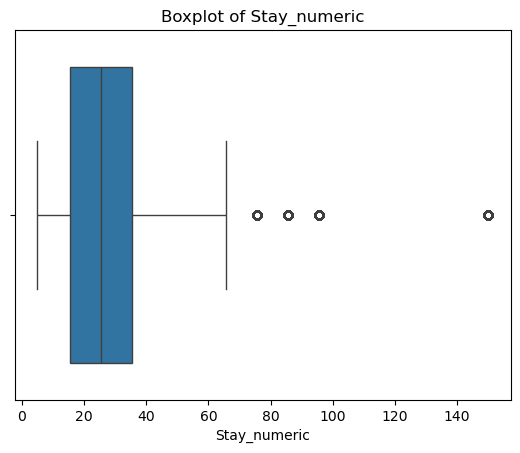

In [36]:
sns.boxplot (x=df['Stay_numeric'])
plt.title('Boxplot of Stay_numeric')
plt.show()

In [37]:
Q1= df['Admission_Deposit'].quantile(0.25)
Q3= df['Admission_Deposit'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Admission_Deposit']<lower_bound)|(df['Admission_Deposit']>upper_bound)]
print (f"Number of outliers in Admission_Deposit: {len(outliers)}")

Number of outliers in Admission_Deposit: 12316


In [38]:
Q1= df['Visitors with Patient'].quantile(0.25)
Q3= df['Visitors with Patient'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Visitors with Patient']<lower_bound)|(df['Visitors with Patient']>upper_bound)]
print (f"Number of outliers in Visitors with Patient: {len(outliers)}")

Number of outliers in Visitors with Patient: 9804


In [39]:
Q1= df['Age_numeric'].quantile(0.25)
Q3= df['Age_numeric'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Age_numeric']<lower_bound)|(df['Age_numeric']>upper_bound)]
print (f"Number of outliers in Age_numeric: {len(outliers)}")

Number of outliers in Age_numeric: 7556


In [40]:
Q1= df['Stay_numeric'].quantile(0.25)
Q3= df['Stay_numeric'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Stay_numeric']<lower_bound)|(df['Stay_numeric']>upper_bound)]
print (f"Number of outliers in Stay_numeric: {len(outliers)}")

Number of outliers in Stay_numeric: 24540


In [41]:
Q1= df['Admission_Deposit'].quantile(0.25)
Q3= df['Admission_Deposit'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df['Admission_Deposit']= df['Admission_Deposit'].clip(lower_bound,upper_bound)
print("capping done for Admission_Deposit")

capping done for Admission_Deposit


In [42]:
Q1= df['Visitors with Patient'].quantile(0.25)
Q3= df['Visitors with Patient'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df['Visitors with Patient']= df['Visitors with Patient'].clip(lower_bound,upper_bound)
print("capping done for Visitors with Patient")

capping done for Visitors with Patient


In [43]:
Q1= df['Age_numeric'].quantile(0.25)
Q3= df['Age_numeric'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df['Age_numeric']= df['Age_numeric'].clip(lower_bound,upper_bound)
print("capping done for Age_numeric")

capping done for Age_numeric


In [44]:
Q1= df['Stay_numeric'].quantile(0.25)
Q3= df['Stay_numeric'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df['Stay_numeric']= df['Stay_numeric'].clip(lower_bound,upper_bound)
print("capping done for Stay_numeric")

capping done for Stay_numeric


In [45]:
Q1= df['Admission_Deposit'].quantile(0.25)
Q3= df['Admission_Deposit'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Admission_Deposit']<lower_bound)|(df['Admission_Deposit']>upper_bound)]
print (f"Number of outliers in Admission_Deposit: {len(outliers)}")

Number of outliers in Admission_Deposit: 0


In [46]:
Q1= df['Visitors with Patient'].quantile(0.25)
Q3= df['Visitors with Patient'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Visitors with Patient']<lower_bound)|(df['Visitors with Patient']>upper_bound)]
print (f"Number of outliers in Visitors with Patient: {len(outliers)}")

Number of outliers in Visitors with Patient: 0


In [47]:
Q1= df['Age_numeric'].quantile(0.25)
Q3= df['Age_numeric'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Age_numeric']<lower_bound)|(df['Age_numeric']>upper_bound)]
print (f"Number of outliers in Age_numeric: {len(outliers)}")

Number of outliers in Age_numeric: 0


In [48]:
Q1= df['Stay_numeric'].quantile(0.25)
Q3= df['Stay_numeric'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outliers=df[(df['Stay_numeric']<lower_bound)|(df['Stay_numeric']>upper_bound)]
print (f"Number of outliers in Stay_numeric: {len(outliers)}")

Number of outliers in Stay_numeric: 0


In [49]:
Severity_map ={
    'minor':1,
    'moderate':2,
    'extreme':3
}
df['Severity_numeric'] = df['Severity of Illness'].map(Severity_map)
df[['Severity of Illness', 'Severity_numeric']].head(10)

,Severity of Illness,Severity_numeric
0,extreme,3
1,extreme,3
2,extreme,3
3,extreme,3
4,extreme,3
5,extreme,3
6,extreme,3
7,extreme,3
8,extreme,3
9,extreme,3


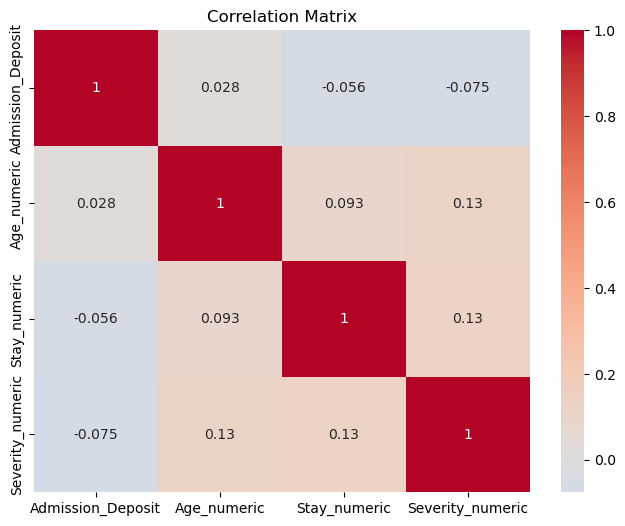

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_clos=['Admission_Deposit','Age_numeric','Stay_numeric','Severity_numeric']
corr_matrix=df[numeric_clos].corr()
plt.figure(figsize=(8,6))  
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [58]:
import scipy.stats as stats
minor= df[df['Severity of Illness']== 'minor']['Stay_numeric']
moderate= df[df['Severity of Illness']== 'moderate']['Stay_numeric']
extreme= df[df['Severity of Illness']== 'extreme']['Stay_numeric']
f_stat, p_value= stats.f_oneway(minor, moderate, extreme)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:{p_value:.4f}")

F-statistic: 2640.9384
P-value:0.0000


In [61]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=df['Stay_numeric'],
                          groups=df['Severity of Illness'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj  lower   upper  reject
------------------------------------------------------
extreme    minor  -6.5545   0.0 -6.7711 -6.3379   True
extreme moderate  -2.9828   0.0 -3.1761 -2.7895   True
  minor moderate   3.5718   0.0  3.4051  3.7384   True
------------------------------------------------------


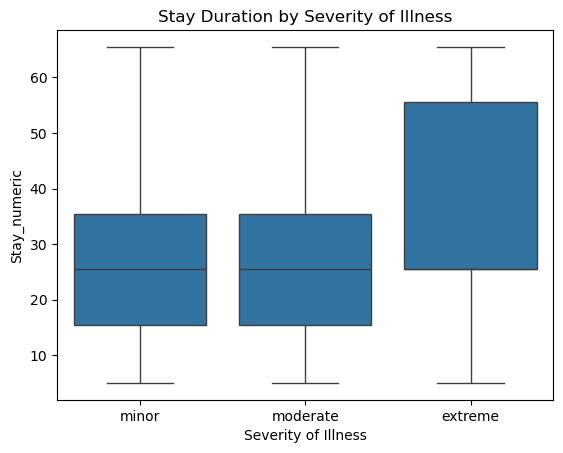

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='Severity of Illness',y='Stay_numeric', data=df, order=['minor','moderate','extreme'])
plt.title('Stay Duration by Severity of Illness')
plt.show()